<h1 style="text-align: center;">Physical AI의 Vision-LLM 융합 시청각 멀티모달 시스템</h1>

<br><br>

<div style="text-align: right; color: gray; font-style: italic;">
강사 김규래<br>
kkr.kyurae.kim@gmail.com
</div><br>

---
---


## 6. Vision-LLM 융합 멀티모달 시스템

### A. Vision-to-Text

#### $1)$ YOLO 탐지 결과 구조

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading src/models/YOLO/yolo11n_int8.engine for TensorRT inference...
[08/14/2026-15:14:19] [TRT] [I] Loaded engine size: 4 MiB
[08/14/2026-15:14:19] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[08/14/2026-15:14:19] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +9, now: CPU 0, GPU 12 (MiB)

image 1/1 /home/chjin/vision-llm/src/images/city.png: 640x640 2 persons, 4 cars, 1 fire hydrant, 1 potted plant, 23.7ms
Speed: 51.9ms preprocess, 23.7ms inference, 35.1ms postprocess per image at shape (1, 3, 640, 640)


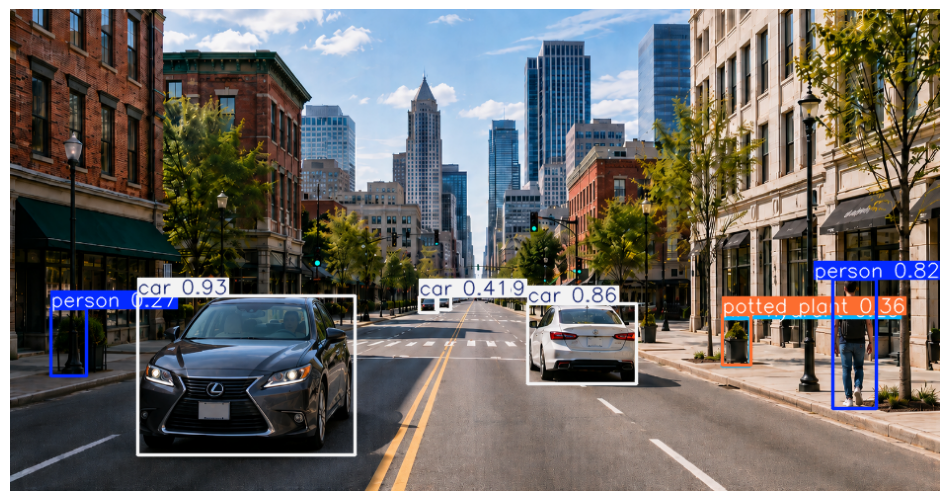

In [1]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


model = YOLO("src/models/YOLO/yolo11n_int8.engine")

results = model.predict(
    source="src/images/city.png",
    conf=0.25,
    iou=0.5,
    classes=None,
)

yolo_test_img = results[0].plot()

yolo_test_img_rgb = cv2.cvtColor(yolo_test_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(yolo_test_img_rgb)
plt.axis("off");

In [2]:
print(results[0].boxes.xyxy)

print(results[0].boxes.conf)

print(results[0].boxes.cls)

tensor([[129.8989, 290.4631, 349.4556, 451.6131],
        [524.1862, 298.9693, 634.4155, 379.2106],
        [833.1264, 273.2472, 877.1353, 404.0380],
        [414.7689, 291.4205, 433.9696, 307.5378],
        [431.7390, 291.4286, 446.1049, 304.5632],
        [721.9315, 309.0139, 750.2545, 360.6446],
        [721.6707, 313.0089, 749.9097, 361.6243],
        [ 41.4009, 303.4251,  77.4706, 371.5177]], device='cuda:0')
tensor([0.9299, 0.8643, 0.8168, 0.4140, 0.3950, 0.3579, 0.2919, 0.2745], device='cuda:0')
tensor([ 2.,  2.,  0.,  2.,  2., 58., 10.,  0.], device='cuda:0')


#### $2)$ YOLO 결과를 JSON 구조로 변환

원하는 구조:
```python
{
    "image_width": 1280,
    "image_height": 720,
    "objects": [
        {
            "class": "person",
            "confidence": 0.92,
            "bbox": {
                "x1": 100,
                "y1": 80,
                "x2": 450,
                "y2": 700
            }
        }
    ]
}
```

In [3]:
from ultralytics import YOLO
import cv2
import json


model = YOLO("src/models/YOLO/yolo11n_int8.engine")


image = cv2.imread("src/images/city.png")

height, width = image.shape[:2]

results = model.predict(
    source=image,
    conf=0.25,
    iou=0.5,
    verbose=False,
)

result = results[0]


objects = []

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = (box.xyxy[0].cpu().tolist())

    objects.append(
        {
            "class": result.names[class_id],
            "confidence": round(confidence, 3),
            "bbox": {
                "x1": int(x1),
                "y1": int(y1),
                "x2": int(x2),
                "y2": int(y2),
            }
        }
    )


vision_data = {
    "image_width": width,
    "image_height": height,
    "objects": objects,
}


vision_json = json.dumps(
    vision_data,
    ensure_ascii=False,
    indent=4,
)


print(vision_json)

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading src/models/YOLO/yolo11n_int8.engine for TensorRT inference...
[08/14/2026-15:14:45] [TRT] [I] Loaded engine size: 4 MiB
[08/14/2026-15:14:45] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[08/14/2026-15:14:45] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +9, now: CPU 0, GPU 12 (MiB)
{
    "image_width": 942,
    "image_height": 488,
    "objects": [
        {
            "class": "car",
            "confidence": 0.93,
            "bbox": {
                "x1": 129,
                "y1": 290,
                "x2": 349,
                "y2": 451
            }
        },
        {
            "class": "car",
            "confidence": 0.864,
  

#### $3)$ JSON - 자연어 변환

단순 Template:
```python
text = (
    f"{class_name} 객체가 "
    f"confidence {confidence:.2f}로 "
    f"탐지되었습니다."
)
```

In [4]:
def detections_to_text(vision_data):
    objects = vision_data["objects"]

    if len(objects) == 0:
        return "현재 탐지된 객체가 없습니다."

    sentences = []

    for index, obj in enumerate(objects, start=1):
        sentence = f"{index}번 객체는 {obj['class']}이며, confidence는 {obj['confidence']:.2f}입니다."

        sentences.append(sentence)

    return "\n".join(sentences)

In [ ]:
vision_text = detections_to_text(vision_data)

print(vision_text)

1번 객체는 car이며, confidence는 0.93입니다.
2번 객체는 car이며, confidence는 0.86입니다.
3번 객체는 person이며, confidence는 0.82입니다.
4번 객체는 car이며, confidence는 0.41입니다.
5번 객체는 car이며, confidence는 0.40입니다.
6번 객체는 potted plant이며, confidence는 0.36입니다.
7번 객체는 fire hydrant이며, confidence는 0.29입니다.
8번 객체는 person이며, confidence는 0.27입니다.


#### $3)$ JSON - LLM 연결

JSON 구조를 통해 자연어로 변환된 Vision 결과를 이전 섹션에서 배운 Context로써 Prompt에 추가하여 LLM에 전달합니다.

```text
예시:

Instruction:
주어진 객체 탐지 정보를 바탕으로
현재 상황을 설명하세요.

Context:
1번 객체는 car이며, confidence는 0.93입니다.
2번 객체는 car이며, confidence는 0.88입니다.
3번 객체는 person이며, confidence는 0.81입니다.
4번 객체는 car이며, confidence는 0.41입니다.
5번 객체는 car이며, confidence는 0.40입니다.
6번 객체는 potted plant이며, confidence는 0.38입니다.

Constraint:
탐지 결과에 없는 객체를 추측하지 마세요.

Output Format:
한국어 두 문장 이내
```

In [ ]:
from llama_cpp import Llama


MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
CONTEXT_WINDOW = 2048  # 프롬프트와 생성 답변을 포함한 최대 컨텍스트 길이
MAX_TOKENS = 150  # LLM이 생성할 답변의 최대 토큰 수


llm = Llama(
    model_path=MODEL_PATH,  # 로컬 Gemma GGUF 모델 경로
    n_gpu_layers=-1,  # 가능한 모든 모델 레이어를 GPU에 올려 추론
    n_ctx=CONTEXT_WINDOW,
    n_batch=32,
    n_ubatch=32,
    verbose=False,
)


prompt = f"""
Instruction:
주어진 객체 탐지 정보를 바탕으로 현재 상황을 설명하세요.

Context:
{vision_text}

Constraint:
탐지 결과에 없는 객체를 추측하지 마세요.

Output Format:
한국어 두 문장 이내
"""  # 앞 셀에서 자연어로 변환한 YOLO 결과를 Context에 삽입


response = llm.create_chat_completion(
    messages=[
        {
            "role": "user",
            "content": prompt,  # vision_text가 포함된 전체 프롬프트를 LLM에 전달
        }
    ],
    max_tokens=MAX_TOKENS,
    temperature=0.2,  # 탐지 결과에 충실하도록 응답의 무작위성을 낮춤
)


answer = response["choices"][0]["message"]["content"].strip()  # 생성 텍스트만 추출
print(answer)

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512


현재 이미지에는 자동차가 세 대(신뢰도 0.93, 0.86, 0.41, 0.40)와 두 명의 사람(신뢰도 0.82, 0.27)이 탐지되었습니다. 또한, 화분 식물(신뢰도 0.36), 소화전(신뢰도 0.29)도 탐지되었으나 신뢰도는 비교적 낮습니다.


In [10]:
CAMERA_INDEX = 0  # Jetson CSI 카메라의 sensor-id
CAMERA_WIDTH = 1280
CAMERA_HEIGHT = 720
CAMERA_FPS = 30


camera_pipeline = (
    f"nvarguscamerasrc sensor-id={CAMERA_INDEX} ! "
    f"video/x-raw(memory:NVMM), width={CAMERA_WIDTH}, height={CAMERA_HEIGHT}, "
    f"framerate={CAMERA_FPS}/1 ! "
    "nvvidconv ! "  # Jetson 하드웨어를 사용해 카메라 프레임 변환
    "video/x-raw, format=BGRx ! "
    "videoconvert ! "
    "video/x-raw, format=BGR ! "  # OpenCV와 YOLO가 사용하는 BGR 형식으로 변환
    "queue leaky=downstream max-size-buffers=1 ! "  # 오래된 프레임이 쌓이지 않도록 제거
    "appsink drop=true max-buffers=1 sync=false"
)


def result_to_vision_data(result, frame):
    """한 프레임의 YOLO 탐지 결과를 기존 vision_data 형식으로 변환합니다."""
    height, width = frame.shape[:2]
    objects = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().tolist()  # GPU 텐서를 CPU 좌표 목록으로 변환

        objects.append(
            {
                "class": result.names[class_id],
                "confidence": round(confidence, 3),
                "bbox": {
                    "x1": int(x1),
                    "y1": int(y1),
                    "x2": int(x2),
                    "y2": int(y2),
                },
            }
        )

    return {
        "image_width": width,
        "image_height": height,
        "objects": objects,
    }


camera = cv2.VideoCapture(
    camera_pipeline,
    cv2.CAP_GSTREAMER,
)  # Jetson CSI 카메라를 GStreamer 파이프라인으로 열기

if not camera.isOpened():
    raise RuntimeError(
        f"CSI 카메라 sensor-id={CAMERA_INDEX}를 열 수 없습니다. "
        "카메라 연결과 nvargus-daemon 상태를 확인하세요."
    )


print("'l': 현재 탐지 결과를 LLM에 전달 / 'q': 종료")

try:
    while True:
        success, frame = camera.read()  # 카메라에서 최신 프레임 읽기

        if not success:
            print("카메라 프레임을 읽지 못했습니다.")
            break

        results = model.predict(
            source=frame,
            conf=0.25,
            iou=0.5,
            verbose=False,
        )  # 현재 프레임에서 객체 탐지 수행
        result = results[0]
        annotated_frame = result.plot()  # 바운딩 박스와 클래스 이름이 표시된 화면 생성

        cv2.putText(
            annotated_frame,
            "[l] Ask LLM  [q] Quit",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2,
        )
        cv2.imshow("Vision-LLM Camera", annotated_frame)

        key = cv2.waitKey(1) & 0xFF  # 키 입력의 하위 8비트만 사용

        if key == ord("q"):
            break

        if key == ord("l"):
            vision_data = result_to_vision_data(result, frame)  # 키를 누른 시점의 탐지 결과 저장
            vision_text = detections_to_text(vision_data)  # 구조화된 결과를 LLM용 자연어 Context로 변환

            prompt = f"""
Instruction:
주어진 객체 탐지 정보를 바탕으로 현재 상황을 설명하세요.

Context:
{vision_text}

Constraint:
탐지 결과에 없는 객체를 추측하지 마세요.

Output Format:
한국어 두 문장 이내
"""

            print("\n[Vision Context]")
            print(vision_text)
            print("\nLLM 응답 생성 중...")

            response = llm.create_chat_completion(
                messages=[{"role": "user", "content": prompt}],  # 현재 프레임의 Context 전달
                max_tokens=MAX_TOKENS,
                temperature=0.2,
            )
            answer = response["choices"][0]["message"]["content"].strip()

            print("\n[Gemma]")
            print(answer)

finally:
    camera.release()  # 오류 또는 정상 종료 시 카메라 장치 반환
    cv2.destroyAllWindows()  # OpenCV로 생성한 모든 창 닫기

GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3280 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3280 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: Running with following settings:
   Camera index = 0 
   Camera mode  = 4 
   Output Stream W = 1280 H = 7

[ WARN:0@574.614] global cap_gstreamer.cpp:1728 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


'l': 현재 탐지 결과를 LLM에 전달 / 'q': 종료

[Vision Context]
현재 탐지된 객체가 없습니다.

LLM 응답 생성 중...

[Gemma]
현재 탐지된 객체가 없습니다. 따라서 현재 상황에 대해 설명할 수 있는 정보가 없습니다.

[Vision Context]
1번 객체는 person이며, confidence는 0.74입니다.

LLM 응답 생성 중...

[Gemma]
현재 이미지에는 신뢰도 0.74로 사람 한 명이 탐지되었습니다.
GST_ARGUS: Cleaning up
CONSUMER: Done Success
GST_ARGUS: Done Success


### B. Image 기반 Vision-Language 멀티모달 시스템

In [11]:
# city.png 전체를 이미지로 Gemma에 전달


from llama_cpp import Llama
from llama_cpp.llama_chat_format import Gemma4ChatHandler

import cv2
import base64


MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
MMPROJ_PATH = "src/models/Gemma4/mmproj-google_gemma-4-E2B-it-f16.gguf"
IMAGE_PATH = "src/images/city.png"
CONTEXT_WINDOW = 2048
MAX_TOKENS = 150


chat_handler = Gemma4ChatHandler(clip_model_path=MMPROJ_PATH)


llm = Llama(
    model_path=MODEL_PATH,
    chat_handler=chat_handler,
    n_gpu_layers=-1,
    n_ctx=CONTEXT_WINDOW,
    n_batch=32,
    n_ubatch=32,
    verbose=False,
)



image = cv2.imread(IMAGE_PATH)

success, buffer = cv2.imencode(".jpg", image)

if not success:
    raise RuntimeError("이미지 인코딩에 실패했습니다.")

image_base64 = base64.b64encode(buffer).decode("utf-8")

image_data = ("data:image/jpeg;base64," + image_base64)


response = llm.create_chat_completion(
    messages=[
        {
            "role": "system",
            "content": """
                        Instruction:
                        주어진 이미지를 바탕으로 현재 상황을 설명해.

                        Constraint:
                        이미지에서 명확하게 확인되지 않는 내용은 추측하지 마.

                        Output Format:
                        한국어 두 문장 이내
                       """
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": (
                        "현재 카메라 이미지를 설명하시오."
                    ),
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_data
                    },
                },
            ],
        }
    ],
    max_tokens=MAX_TOKENS,
    temperature=0.7,
)


print(response["choices"][0]["message"]["content"])

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512
add_text: <|turn>system
Instruction:
                        주어진 이미지를 바탕으로 현재 상황을 설명해.

                        Constraint:
                        이미지에서 명확하게 확인되지 않는 내용은 추측하지 마.

                        Output Format:
                        한국어 두 문장 이내<turn|>
<|turn>user
현재 카메라 이미지를 설명하시오.
add_text: <|image>
add_media: preproc_out has 1 entries, grid_x = 0, grid_y = 0, has_overview = 0
image_tokens->nx = 200
image_tokens->ny = 1
batch_f32 size = 1
add_text: <image|>
add_text: <turn|>
<|turn>model

encoding image slice...
clip_image_batch_encode: copying image 1/1 to input buffer (nx=960, ny=480)
clip_image_batch_encode: output embedd

이 이미지는 도심의 거리를 보여주며, 양쪽에 건물들이 늘어서 있고 멀리 고층 빌딩들이 보입니다. 도로 위에는 차량들이 주행하고 있으며, 가로수들이 길을 따라 심어져 있습니다.


In [12]:
# city.png 중 신호등 ROI를 이미지로 Gemma에 전달


import cv2
import base64

from ultralytics import YOLO
from llama_cpp import Llama
from llama_cpp.llama_chat_format import Gemma4ChatHandler


YOLO_MODEL_PATH = "src/models/YOLO/yolo11n.pt"

GEMMA_MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
MMPROJ_PATH = "src/models/Gemma4/mmproj-google_gemma-4-E2B-it-f16.gguf"
IMAGE_PATH = "src/images/city.png"
CONTEXT_WINDOW = 2048
MAX_TOKENS = 20
DISPLAY_WIDTH = 600
DISPLAY_HEIGHT = 600


yolo = YOLO(YOLO_MODEL_PATH)
yolo.to("cuda")


chat_handler = Gemma4ChatHandler(clip_model_path=MMPROJ_PATH)


llm = Llama(
    model_path=GEMMA_MODEL_PATH,
    chat_handler=chat_handler,
    n_gpu_layers=-1,
    n_ctx=CONTEXT_WINDOW,
    n_batch=32,
    n_ubatch=32,
    verbose=False,
)


image = cv2.imread(IMAGE_PATH)

if image is None:
    raise RuntimeError("이미지를 불러올 수 없습니다.")


results = yolo.predict(
    source=image,
    conf=0.03,
    iou=0.5,
    classes=[9],
    verbose=False,
)

result = results[0]


if len(result.boxes) == 0:
    raise RuntimeError("신호등이 탐지되지 않았습니다.")


selected_box = min(result.boxes, key=lambda box: float(box.xyxy[0][1].item()))

confidence = float(selected_box.conf[0].item())

x1, y1, x2, y2 = (selected_box.xyxy[0].cpu().tolist())

x1 = int(x1)
y1 = int(y1)
x2 = int(x2)
y2 = int(y2)


print(f"Traffic Light Confidence: {confidence:.2f}")
print(f"BBox: ({x1}, {y1}) ({x2}, {y2})")


height, width = image.shape[:2]

x1 = max(0, x1)
y1 = max(0, y1)

x2 = min(width, x2)
y2 = min(height, y2)

traffic_light_image = image[y1:y2, x1:x2].copy()

if traffic_light_image.size == 0:
    raise RuntimeError("BBox 이미지를 만들 수 없습니다.")


display_image = cv2.resize(traffic_light_image, (DISPLAY_WIDTH, DISPLAY_HEIGHT), interpolation=cv2.INTER_NEAREST)

cv2.namedWindow("Traffic Light", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Traffic Light", DISPLAY_WIDTH, DISPLAY_HEIGHT)
cv2.imshow("Traffic Light", display_image)

print("q : 이미지 창 닫기")

while True:
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cv2.destroyWindow("Traffic Light")


success, buffer = cv2.imencode(".jpg", traffic_light_image)

if not success:
    raise RuntimeError("이미지 인코딩에 실패했습니다.")

image_base64 = base64.b64encode(buffer).decode("utf-8")

image_data = "data:image/jpeg;base64," + image_base64

response = llm.create_chat_completion(
    messages=[
        {
            "role": "system",
            "content": """
                        Instruction:
                        주어진 신호등 이미지의 현재 색을 판단해.

                        Constraint:
                        반드시 다음 세 가지 중 하나만 대답해.
                        빨간불
                        노란불
                        파란불

                        다른 설명이나 문장을 추가하지 마.

                        Output Format:
                        한 단어
                       """
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": (
                        "현재 신호등의 색을 판단하시오."
                    ),
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_data
                    },
                },
            ],
        }
    ],
    max_tokens=MAX_TOKENS,
    temperature=0.0,
)


answer = response["choices"][0]["message"]["content"].strip()

print("\n[Gemma]")
print(answer)

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512


: 

In [ ]:
# TODO: 카메라 프레임 내 YOLO 감지 객체 하나를 선택하여 이미지로 LLM에 전달

### C. STT, TTS

#### $1)$ `Whisper.cpp` 패키지 설치:

```bash
git clone https://github.com/ggml-org/whisper.cpp.git
```

```bash
sudo apt install -y cmake
export PATH=/usr/local/cuda-12.6/bin:$PATH
export LD_LIBRARY_PATH=/usr/local/cuda-12.6/lib64:$LD_LIBRARY_PATH
cd whisper.cpp
```

1. CPU 버전으로 빌드:

```bash
cmake -B build-cpu

cmake --build build-cpu --target whisper-cli -j4 --config Release
```

2. CUDA 버전으로 빌드:

```bash
cmake -B build -DGGML_CUDA=1

cmake --build build -j4 --config Release
```

빌드가 끝나면 `whisper-cli` 파일이 생성됩니다.

파일 생성 확인:

CPU:
```bash
ls -lh build-cpu/bin/whisper-cli
```

CUDA:
```bash
ls -lh build/bin/whisper-cli
```

한국어 Whisper 모델 다운로드:

```bash
sh ./models/download-ggml-model.sh base
```

#### 간단한 STT 테스트:

```bash
mkdir ../src/audio
```

5초간 음성 녹음:

```bash
arecord \
    -D plughw:1,0 \
    -f S16_LE \
    -r 16000 \
    -c 1 \
    -d 5 \
    ../src/audio/input.wav
```

STT 테스트:

```bash
./build-cpu/bin/whisper-cli \
    -m models/ggml-base.bin \
    -f ../src/audio/input.wav \
    -l ko \
    -nt
```

#### $2)$ `Piper` 패키지 설치:

별도 가상환경 생성:

```bash
deactivate
python3 -m venv .piper_venv
source .piper_venv/bin/activate
```

`Piper` 설치:

```bash
pip install piper-tts
```

한국어 음성 다운로드:

```bash
cd ..
mkdir -p src/models/Piper
python3 -m piper.download_voices \
    ko_KR-kss-medium \
    --data-dir src/models/Piper
```

TTS 테스트:

```bash
python3 -m piper \
    -m src/models/Piper/ko_KR-kss-medium.onnx \
    -f src/audio/response.wav \
    -- \
    "안녕하세요. 반갑습니다."
```

```bash
aplay src/audio/response.wav
```

#### $3)$ Python 환경에서의 STT, TTS

앞서 명령어로 STT와 TTS가 문제 없이 실행되었다면, 이제 Python 코드로 동일한 작업을 수행해보도록 합시다.

#### STT:

In [3]:
import subprocess


MIC_DEVICE = "plughw:1,0"  # USB Microphone: card 1, device 0
AUDIO_FILE = "src/audio/input.wav"
WHISPER_PATH = "whisper.cpp/build-cpu/bin/whisper-cli"
WHISPER_MODEL = "whisper.cpp/models/ggml-base.bin"
RECORD_SECONDS = 5


print("말씀을 시작해 주세요!")


subprocess.run(
    [
        "pasuspender", "--",
        "arecord",
        "-D", MIC_DEVICE,
        "-f", "S16_LE",
        "-r", "16000",
        "-c", "1",
        "-d", str(RECORD_SECONDS),
        AUDIO_FILE,
    ],
    check=True,
)

result = subprocess.run(
    [
        WHISPER_PATH,
        "-m", WHISPER_MODEL,
        "-f", AUDIO_FILE,
        "-l", "ko",
        "--no-timestamps",
    ],
    text=True,
    capture_output=True,
    check=True,
)


text = result.stdout.strip()

print("STT 결과:")
print(text)

말씀을 시작해 주세요!


Recording WAVE 'src/audio/input.wav' : Signed 16 bit Little Endian, Rate 16000 Hz, Mono


STT 결과:
여기에서 시작하셔서 너무...


#### TTS:

In [7]:
import subprocess


PIPER_PYTHON = "whisper.cpp/.piper_venv/bin/python"  # 실제 Piper 가상환경 위치
PIPER_MODEL = "src/models/Piper/ko_KR-kss-medium.onnx"
OUTPUT_FILE = "src/audio/response.wav"
SPEAKER_DEVICE = "plughw:0,0"  # USB Composite Device: card 0, device 0


text = "현재는 빨간불입니다. 주의하시길 바랍니다!"

subprocess.run(
    [
        PIPER_PYTHON,
        "-m",
        "piper",

        "-m",
        PIPER_MODEL,

        "-f",
        OUTPUT_FILE,

        "--",
        text,
    ],
    check=True,
)

subprocess.run(
    [
        "pasuspender", "--",  # PulseAudio의 USB 장치 점유를 재생 중 잠시 해제
        "aplay",
        "-D",
        SPEAKER_DEVICE,
        OUTPUT_FILE,
    ],
    check=True,
)

2026-08-14 16:12:13.071067746 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card1/device/vendor"
Playing WAVE 'src/audio/response.wav' : Signed 16 bit Little Endian, Rate 22050 Hz, Mono


CompletedProcess(args=['pasuspender', '--', 'aplay', '-D', 'plughw:0,0', 'src/audio/response.wav'], returncode=0)

동일한 코드를 함수로 정의하도록 합시다.

In [8]:
def speech_to_text():
    subprocess.run(
        [
            "pasuspender", "--",
            "arecord",
            "-D", MIC_DEVICE,
            "-f", "S16_LE",
            "-r", "16000",
            "-c", "1",
            "-d", str(RECORD_SECONDS),
            AUDIO_FILE,
        ],
        check=True,
    )

    result = subprocess.run(
        [
            WHISPER_PATH,
            "-m", WHISPER_MODEL,
            "-f", AUDIO_FILE,
            "-l", "ko",
            "--no-timestamps",
        ],
        text=True,
        capture_output=True,
        check=True,
    )


    return result.stdout.strip()

In [9]:
def text_to_speech(text):
    subprocess.run(
        [
            PIPER_PYTHON,
            "-m",
            "piper",

            "-m",
            PIPER_MODEL,

            "-f",
            OUTPUT_FILE,

            "--",
            text,
        ],
        check=True,
    )

    subprocess.run(
        [
            "pasuspender", "--",  # PulseAudio의 USB 장치 점유를 재생 중 잠시 해제
            "aplay",
            "-D",
            SPEAKER_DEVICE,
            OUTPUT_FILE,
        ],
        check=True,
    )

In [10]:
question = speech_to_text()
print(question)
text_to_speech("앞에 사람이 한 명 있습니다.")

Recording WAVE 'src/audio/input.wav' : Signed 16 bit Little Endian, Rate 16000 Hz, Mono


- 저 부탁드립니다. - 저 부탁드립니다. - 그리고 지금 저 부탁드립니다.


2026-08-14 16:12:57.860077464 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card1/device/vendor"
Playing WAVE 'src/audio/response.wav' : Signed 16 bit Little Endian, Rate 22050 Hz, Mono


---

## <center>< Section Project ></center>

전 과정에서 다룬 내용을 바탕으로 Vision-LLM 융합 멀티모달 시스템을 구축합니다.<br>
각 섹션의 메인 주제인 Gemma와 YOLO, 그리고 모든 기법들을 통합하여, 객체를 탐지하고 특정 이벤트를 감지하고 유저 음성 입력을 받아 음성으로 내보내는 파이프라인을 설계합니다.

In [1]:
# Vision + STT + LLM + TTS 통합 프로젝트
# [v] 현재 화면에 관해 음성으로 질문 / [q] 종료

import cv2
import subprocess
from ultralytics import YOLO
from llama_cpp import Llama


# -------------------- 모델 및 장치 설정 --------------------
YOLO_MODEL_PATH = "src/models/YOLO/yolo11n_int8.engine"
GEMMA_MODEL_PATH = "src/models/Gemma4/google_gemma-4-E2B-it-Q4_K_M.gguf"
WHISPER_PATH = "whisper.cpp/build-cpu/bin/whisper-cli"
WHISPER_MODEL = "whisper.cpp/models/ggml-base.bin"
PIPER_PYTHON = "whisper.cpp/.piper_venv/bin/python"
PIPER_MODEL = "src/models/Piper/ko_KR-kss-medium.onnx"

MIC_DEVICE = "plughw:1,0"  # USB Microphone
SPEAKER_DEVICE = "plughw:0,0"  # USB Composite Device
AUDIO_FILE = "src/audio/input.wav"
OUTPUT_FILE = "src/audio/response.wav"
RECORD_SECONDS = 5
MAX_TOKENS = 80

CAMERA_INDEX = 0
CAMERA_WIDTH = 1280
CAMERA_HEIGHT = 720
CAMERA_FPS = 30


# -------------------- 모델 로드 --------------------
project_yolo = YOLO(YOLO_MODEL_PATH)
project_llm = Llama(
    model_path=GEMMA_MODEL_PATH,
    n_gpu_layers=0,  # Jetson 공유 메모리 부족을 줄이기 위해 CPU에서 LLM 추론
    n_ctx=1024,
    n_batch=8,
    n_ubatch=8,
    verbose=False,
)


# -------------------- 멀티모달 처리 함수 --------------------
def project_detections_to_text(result):
    """YOLO 탐지 결과를 Gemma가 읽을 수 있는 Vision Context로 변환합니다."""
    objects = []

    for index, box in enumerate(result.boxes, start=1):
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        objects.append(
            f"{index}번 객체는 {result.names[class_id]}이며, "
            f"confidence는 {confidence:.2f}입니다."
        )

    if not objects:
        return "현재 탐지된 객체가 없습니다."

    return "\n".join(objects)


def project_speech_to_text():
    """USB 마이크로 5초간 녹음하고 Whisper로 한국어 문장을 인식합니다."""
    print("질문을 말씀해 주세요!")
    subprocess.run(
        [
            "pasuspender", "--",  # PulseAudio의 마이크 점유를 녹음 중 해제
            "arecord",
            "-D", MIC_DEVICE,
            "-f", "S16_LE",
            "-r", "16000",
            "-c", "1",
            "-d", str(RECORD_SECONDS),
            AUDIO_FILE,
        ],
        check=True,
    )

    result = subprocess.run(
        [
            WHISPER_PATH,
            "-m", WHISPER_MODEL,
            "-f", AUDIO_FILE,
            "-l", "ko",
            "--no-timestamps",
        ],
        text=True,
        capture_output=True,
        check=True,
    )
    return result.stdout.strip()


def project_ask_llm(question, vision_text):
    """음성 질문과 Vision Context를 하나의 프롬프트로 Gemma에 전달합니다."""
    prompt = f"""
Instruction:
사용자의 질문에 현재 객체 탐지 정보를 근거로 답변하세요.

User Question:
{question}

Vision Context:
{vision_text}

Constraint:
탐지 결과에 없는 객체나 상황을 추측하지 마세요.

Output Format:
한국어 두 문장 이내
"""

    response = project_llm.create_chat_completion(
        messages=[{"role": "user", "content": prompt}],
        max_tokens=MAX_TOKENS,
        temperature=0.2,
    )
    return response["choices"][0]["message"]["content"].strip()


def project_text_to_speech(text):
    """Gemma 답변을 Piper 음성으로 생성하고 USB 스피커로 재생합니다."""
    subprocess.run(
        [
            PIPER_PYTHON, "-m", "piper",
            "-m", PIPER_MODEL,
            "-f", OUTPUT_FILE,
            "--", text,
        ],
        check=True,
    )
    subprocess.run(
        ["pasuspender", "--", "aplay", "-D", SPEAKER_DEVICE, OUTPUT_FILE],
        check=True,
    )


# -------------------- Jetson CSI 카메라 --------------------
camera_pipeline = (
    f"nvarguscamerasrc sensor-id={CAMERA_INDEX} ! "
    f"video/x-raw(memory:NVMM), width={CAMERA_WIDTH}, height={CAMERA_HEIGHT}, "
    f"framerate={CAMERA_FPS}/1 ! "
    "nvvidconv ! "
    "video/x-raw, format=BGRx ! "
    "videoconvert ! "
    "video/x-raw, format=BGR ! "
    "queue leaky=downstream max-size-buffers=1 ! "
    "appsink drop=true max-buffers=1 sync=false"
)

camera = cv2.VideoCapture(camera_pipeline, cv2.CAP_GSTREAMER)
if not camera.isOpened():
    raise RuntimeError("CSI 카메라를 열 수 없습니다.")

print("카메라 창에서 [v] 음성 질문 / [q] 종료")

try:
    while True:
        success, frame = camera.read()
        if not success:
            print("카메라 프레임을 읽지 못했습니다.")
            break

        detection = project_yolo.predict(
            source=frame,
            conf=0.25,
            iou=0.5,
            verbose=False,
        )[0]
        output_frame = detection.plot()
        cv2.putText(
            output_frame,
            "[v] Voice Question  [q] Quit",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2,
        )
        cv2.imshow("Vision-LLM Multimodal Project", output_frame)

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break

        if key == ord("v"):
            # v를 누른 순간의 탐지 결과를 음성 질문과 함께 사용
            vision_text = project_detections_to_text(detection)

            try:
                question = project_speech_to_text()
                print(f"\n[사용자] {question}")
                print(f"\n[Vision Context]\n{vision_text}")

                answer = project_ask_llm(question, vision_text)
                print(f"\n[Gemma] {answer}")
                project_text_to_speech(answer)
            except subprocess.CalledProcessError as error:
                # 한 단계가 실패해도 카메라 루프를 종료하지 않고 오류를 표시
                print(f"오디오 처리 중 오류가 발생했습니다: {error}")

finally:
    camera.release()
    cv2.destroyAllWindows()
    print("멀티모달 시스템을 종료했습니다.")

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.


llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512


GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3280 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3280 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: Running with following settings:
   Camera index = 0 
   Camera mode  = 4 
   Output Stream W = 1280 H = 7

[ WARN:0@14.706] global cap_gstreamer.cpp:1728 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


[08/14/2026-16:19:47] [TRT] [I] Loaded engine size: 4 MiB
[08/14/2026-16:19:47] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[08/14/2026-16:19:47] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +9, now: CPU 0, GPU 12 (MiB)


...

2026-08-14 16:22:18.304558265 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card1/device/vendor"
Playing WAVE 'src/audio/response.wav' : Signed 16 bit Little Endian, Rate 22050 Hz, Mono


질문을 말씀해 주세요!


Recording WAVE 'src/audio/input.wav' : Signed 16 bit Little Endian, Rate 16000 Hz, Mono



[사용자] - 너무 좋아요. - 너무 고생하셨습니다.

[Vision Context]
현재 탐지된 객체가 없습니다.


: 

---
---

<br><br><div style="text-align: right; color: gray; font-style: italic;">
© 2026, 김규래 (Kyu Rae Kim), All rights reserved.&emsp;<br><br>
This material is provided solely for the intended instructional purpose.&emsp;<br>
Redistribution, reproduction, modification, adaptation, or reuse of this material in any form without prior written permission from the copyright holder is prohibited.&emsp;
</div>